**Question 1: What is a Convolutional Neural Network (CNN), and how does it differ from traditional fully connected neural networks in terms of architecture and performance on image data?**

A Convolutional Neural Network (CNN) is a type of deep learning model specifically designed to process image data by using convolutional layers that automatically extract important features such as edges, textures, and shapes. Unlike traditional fully connected neural networks, where each neuron is connected to every neuron in the previous layer, CNNs use local connections and parameter sharing, which significantly reduces the number of parameters and computational cost. In terms of architecture, CNNs consist of convolutional, pooling, and fully connected layers, whereas fully connected networks only consist of dense layers without considering spatial structure. As a result, CNNs perform much better on image data because they preserve spatial relationships and learn hierarchical features, while fully connected networks tend to perform poorly on images due to high complexity and lack of spatial awareness.

---

**Question 2: Discuss the architecture of LeNet-5 and explain how it laid the foundation for modern deep learning models in computer vision. Include references to its original research paper.**

LeNet-5 is an early convolutional neural network developed by Yann LeCun and his colleagues, as presented in the research paper Gradient-Based Learning Applied to Document Recognition. The architecture of LeNet-5 consists of an input layer followed by alternating convolutional and pooling layers, and then fully connected layers leading to the output. Specifically, it takes a 32×32 grayscale image as input, processes it through two convolutional layers (C1 and C3) and two subsampling (pooling) layers (S2 and S4), followed by fully connected layers (C5 and F6), and finally produces an output layer with 10 neurons for classification. This architecture laid the foundation for modern deep learning models by introducing key concepts such as convolution operations, pooling for dimensionality reduction, parameter sharing, and hierarchical feature learning. These ideas are still used in advanced models like AlexNet and ResNet, making LeNet-5 a pioneering model in the field of computer vision.


**Question 3: Compare and contrast AlexNet and VGGNet in terms of design principles, number of parameters, and performance. Highlight key innovations and limitations of each.**

AlexNet and VGGNet are both important convolutional neural network architectures, but they differ in design principles, complexity, and performance. AlexNet, developed by Alex Krizhevsky along with Geoffrey Hinton, introduced a relatively deep architecture with 8 layers and used larger convolutional filters (such as 11×11 and 5×5). It has around 60 million parameters and was a breakthrough model that significantly improved image classification performance on the ImageNet dataset. Its key innovations include the use of ReLU activation for faster training, dropout for reducing overfitting, and GPU acceleration. However, its limitations include relatively large filters and less uniform architecture, which can reduce efficiency.

In contrast, VGGNet, developed by Visual Geometry Group, follows a simpler and more uniform design using very small 3×3 convolutional filters stacked deeper, typically with 16 or 19 layers. Although VGGNet achieves higher accuracy and better feature representation than AlexNet, it has a much larger number of parameters (around 138 million), making it computationally expensive and memory-intensive. Its key innovation is demonstrating that increasing depth with small filters improves performance, but its main limitation is the high computational cost and slower training. Overall, AlexNet is more efficient and pioneering, while VGGNet is deeper and more accurate but resource-heavy.

---

**Question 4: What is transfer learning in the context of image classification? Explain how it helps in reducing computational costs and improving model performance with limited data.**

Transfer learning in the context of image classification is a technique where a pre-trained model, such as ResNet or VGGNet, is reused for a new but related task instead of training a model from scratch. In this approach, the model is first trained on a large dataset like ImageNet to learn general features such as edges, textures, and shapes, and then it is fine-tuned or partially retrained on a smaller, task-specific dataset.

This method helps reduce computational costs because the model has already learned useful feature representations, so only the final layers need to be trained or adjusted, saving time and processing power. It also improves performance when limited data is available, as the pre-trained model provides a strong starting point and prevents overfitting, allowing the model to generalize better even with a small dataset. Thus, transfer learning is widely used in practical applications where data and computational resources are limited.


Question 5: Describe the role of residual connections in ResNet architecture. How do they address the vanishing gradient problem in deep CNNs?

Residual connections are a key feature of ResNet that allow the input of a layer to be directly added to the output of a deeper layer, forming what is called a “skip connection.” Instead of learning a direct mapping, the network learns a residual function (i.e., the difference between input and output), which makes training very deep networks easier. These connections help address the vanishing gradient problem by allowing gradients to flow directly through the network without being diminished during backpropagation. As a result, even very deep CNNs can be trained effectively because the gradient can bypass multiple layers and reach earlier layers without becoming too small. This improves convergence, prevents degradation of accuracy in deeper networks, and enables the successful training of models with hundreds of layers.

Question 6: Implement the LeNet-5 architecture using TensorFlow or PyTorch to classify the MNIST dataset. Report the accuracy and training time.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import time

# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess data
x_train = x_train.reshape(-1, 32, 32, 1) / 255.0
x_test = x_test.reshape(-1, 32, 32, 1) / 255.0

# Pad images to 32x32 (LeNet-5 input size)
x_train = tf.image.resize_with_pad(x_train, 32, 32)
x_test = tf.image.resize_with_pad(x_test, 32, 32)

# Build LeNet-5 model
model = models.Sequential([
    layers.Conv2D(6, kernel_size=(5,5), activation='tanh', input_shape=(32,32,1)),
    layers.AveragePooling2D(),
    layers.Conv2D(16, kernel_size=(5,5), activation='tanh'),
    layers.AveragePooling2D(),
    layers.Flatten(),
    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
start_time = time.time()
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)
end_time = time.time()

# Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)
print("Training Time (seconds):", end_time - start_time)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


ValueError: cannot reshape array of size 47040000 into shape (32,32,1)

Question 7: Use a pre-trained VGG16 model (via transfer learning) on a small custom
dataset (e.g., flowers or animals). Replace the top layers and fine-tune the model.
Include your code and result discussion.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import time

# Image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data generators (example folder structure: dataset/train, dataset/val)
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    'dataset/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Load pre-trained VGG16 without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom top layers
x = base_model.output
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(train_data.num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train only top layers
start_time = time.time()
history = model.fit(train_data, validation_data=val_data, epochs=5)
end_time = time.time()

# Fine-tuning: unfreeze last few layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train again (fine-tuning)
history_fine = model.fit(train_data, validation_data=val_data, epochs=3)

# Evaluate
val_loss, val_acc = model.evaluate(val_data)

print("Validation Accuracy:", val_acc)
print("Training Time (seconds):", end_time - start_time)

Question 8: Write a program to visualize the filters and feature maps of the first
convolutional layer of AlexNet on an example input image.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 134MB/s]


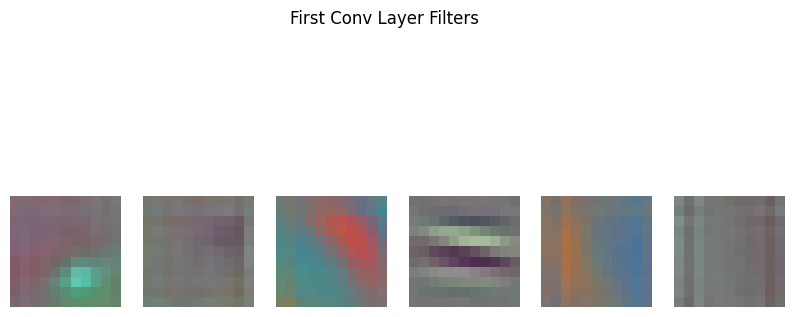

FileNotFoundError: [Errno 2] No such file or directory: 'example.jpg'

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load pretrained AlexNet
model = models.alexnet(pretrained=True)
model.eval()

# Get first convolutional layer
first_conv_layer = model.features[0]

# Visualize filters (weights)
filters = first_conv_layer.weight.data.clone()

# Normalize filters for visualization
filters = (filters - filters.min()) / (filters.max() - filters.min())

# Plot first 6 filters
plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(1,6,i+1)
    filt = filters[i].permute(1,2,0)  # Convert to HWC
    plt.imshow(filt)
    plt.axis('off')
plt.suptitle("First Conv Layer Filters")
plt.show()

# Load and preprocess image
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

img = Image.open("example.jpg").convert("RGB")
img_tensor = transform(img).unsqueeze(0)

# Get feature maps
with torch.no_grad():
    feature_maps = first_conv_layer(img_tensor)

# Plot feature maps (first 6)
feature_maps = feature_maps.squeeze(0)

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(feature_maps[i].cpu(), cmap='gray')
    plt.axis('off')
plt.suptitle("Feature Maps from First Conv Layer")
plt.show()